In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Con to DB
engine = create_engine('postgresql://alexbenz@localhost:5432/alexbenz')

# Check connection
df = pd.read_sql('SELECT COUNT(*) FROM superstore', engine)
print(df)

   count
0   9994


In [3]:
# Load whole data to pd
df = pd.read_sql('SELECT * FROM superstore', engine)
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
# Basic info about data
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(9994, 21)
row_id             int64
order_id             str
order_date        object
ship_date         object
ship_mode            str
customer_id          str
customer_name        str
segment              str
country              str
city                 str
state                str
postal_code          str
region               str
product_id           str
category             str
sub_category         str
product_name         str
sales            float64
quantity           int64
discount         float64
profit           float64
dtype: object
row_id           0
order_id         0
order_date       0
ship_date        0
ship_mode        0
customer_id      0
customer_name    0
segment          0
country          0
city             0
state            0
postal_code      0
region           0
product_id       0
category         0
sub_category     0
product_name     0
sales            0
quantity         0
discount         0
profit           0
dtype: int64


In [5]:
# order_date & ship_date have obj type. So, I converted it to datetime format
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])

# Check
print(df['order_date'].dtype)
print(df['order_date'].min(), '→', df['order_date'].max())

datetime64[s]
2014-01-03 00:00:00 → 2017-12-30 00:00:00


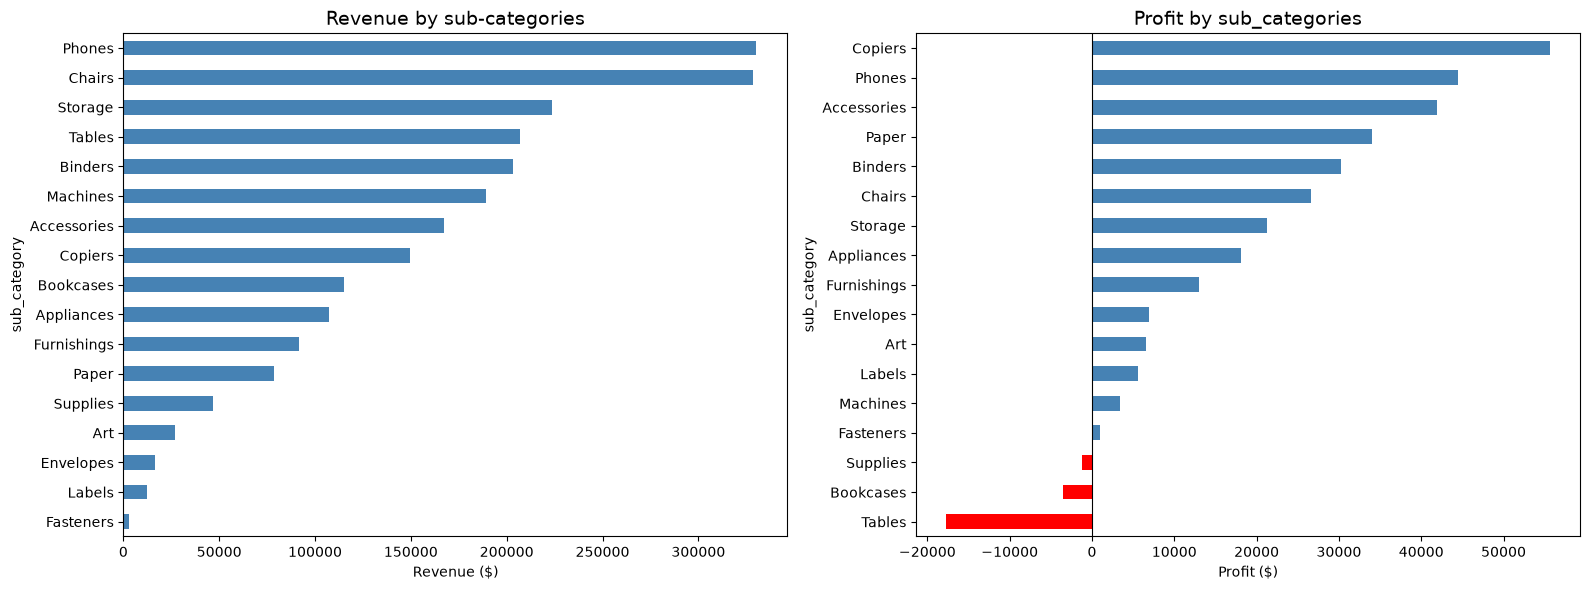

In [7]:
# Graph 1 - Revenue & Profit by sub-categories
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue
sales_by_sub = df.groupby('sub_category')['sales'].sum().sort_values(ascending=True)
sales_by_sub.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Revenue by sub-categories', fontsize=14)
axes[0].set_xlabel('Revenue ($)')

# Profit
profit_by_sub = df.groupby('sub_category')['profit'].sum().sort_values(ascending=True)
colors = ['red' if x < 0 else 'steelblue' for x in profit_by_sub]
profit_by_sub.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Profit by sub_categories', fontsize=14)
axes[1].set_xlabel('Profit ($)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('../images/01_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

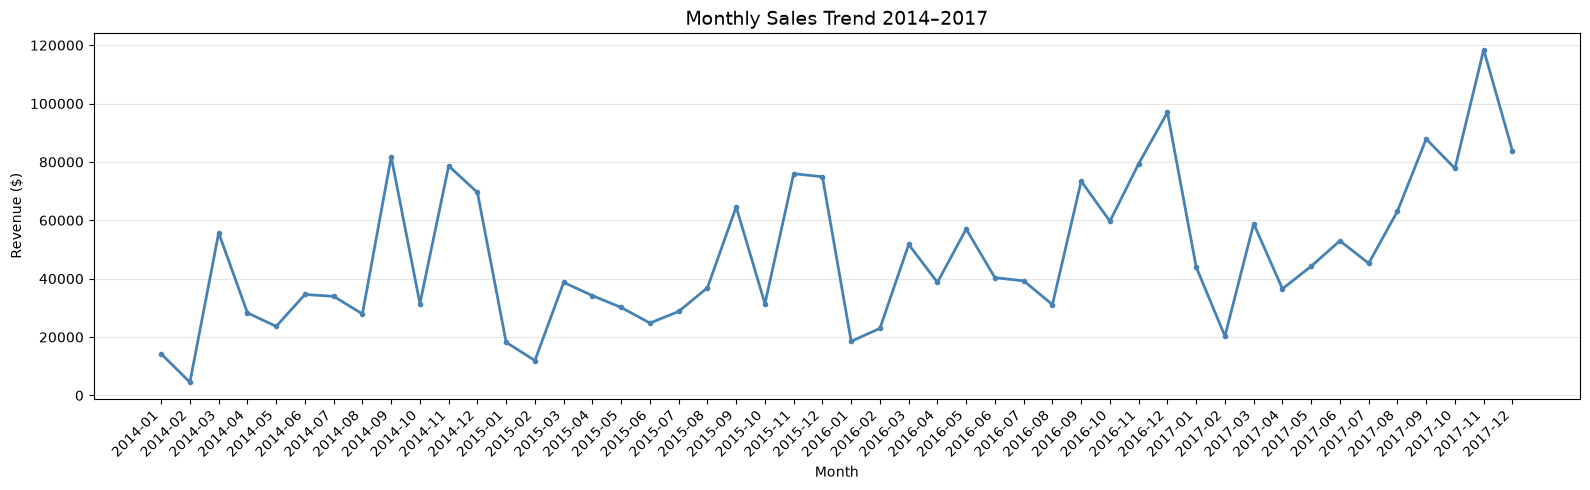

In [8]:
# Graph 2 - MoM sales trend
monthly = df.groupby(df['order_date'].dt.to_period('M'))['sales'].sum().reset_index()
monthly['order_date'] = monthly['order_date'].astype(str)

plt.figure(figsize=(16, 5))
plt.plot(monthly['order_date'], monthly['sales'], color='steelblue', linewidth=2, marker='o', markersize=3)
plt.title('Monthly Sales Trend 2014–2017', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/02_mom_sales.png', dpi=150, bbox_inches='tight')
plt.show()

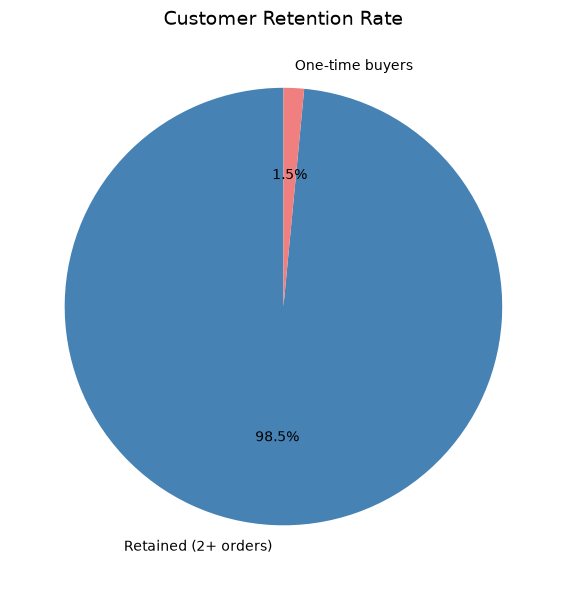

In [10]:
# Graph 3 - Customer retention
total_customers = df['customer_id'].nunique()
returned = df.groupby('customer_id')['order_id'].nunique()
retained = (returned >= 2).sum()

retention_data = pd.DataFrame({
    'Segment': ['Retained (2+ orders)', 'One-time buyers'],
    'Customers': [retained, total_customers - retained]
})

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'lightcoral']
plt.pie(retention_data['Customers'], 
        labels=retention_data['Segment'],
        autopct='%1.1f%%',
        colors=colors,
        startangle=90)
plt.title('Customer Retention Rate', fontsize=14)
plt.tight_layout()
plt.savefig('../images/03_retention.png', dpi=300, bbox_inches='tight')
plt.show()

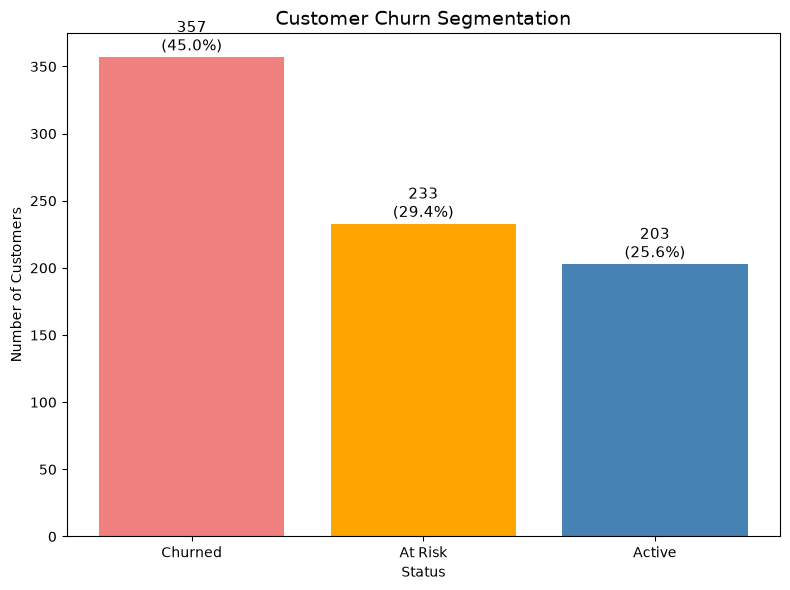

In [11]:
# Graph 4 — Churn segmentation
dataset_end = df['order_date'].max()
last_purchase = df.groupby('customer_id')['order_date'].max().reset_index()
last_purchase['days_since'] = (dataset_end - last_purchase['order_date']).dt.days

last_purchase['status'] = last_purchase['days_since'].apply(
    lambda x: 'Churned' if x > 90 else ('At Risk' if x > 30 else 'Active')
)

churn_summary = last_purchase['status'].value_counts().reset_index()
churn_summary.columns = ['Status', 'Customers']

plt.figure(figsize=(8, 6))
colors = {'Active': 'steelblue', 'At Risk': 'orange', 'Churned': 'lightcoral'}
bars = plt.bar(churn_summary['Status'], 
               churn_summary['Customers'],
               color=[colors[s] for s in churn_summary['Status']])

for bar, val in zip(bars, churn_summary['Customers']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val}\n({val/len(last_purchase)*100:.1f}%)',
             ha='center', fontsize=11)

plt.title('Customer Churn Segmentation', fontsize=14)
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('../images/04_churn.png', dpi=300, bbox_inches='tight')
plt.show()

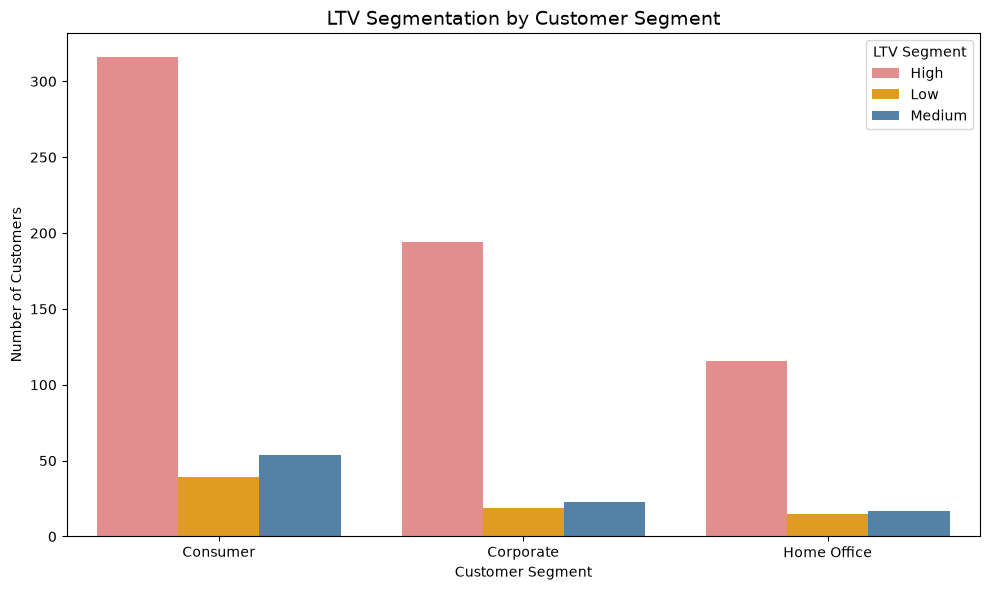

In [13]:
# Graph 5 — LTV Segmentation by customer segment
ltv = df.groupby(['customer_id', 'segment'])['sales'].sum().reset_index()
ltv.columns = ['customer_id', 'segment', 'ltv']

ltv['ltv_segment'] = ltv['ltv'].apply(
    lambda x: 'High' if x >= 1000 else ('Medium' if x >= 500 else 'Low')
)

ltv_summary = ltv.groupby(['segment', 'ltv_segment'])['customer_id'].count().reset_index()
ltv_summary.columns = ['Segment', 'LTV Segment', 'Customers']

plt.figure(figsize=(10, 6))
sns.barplot(data=ltv_summary, x='Segment', y='Customers', 
            hue='LTV Segment', palette=['lightcoral', 'orange', 'steelblue'])
plt.title('LTV Segmentation by Customer Segment', fontsize=14)
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.legend(title='LTV Segment')
plt.tight_layout()
plt.savefig('../images/05_ltv_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()